## Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math 
from random import random 
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path 
import librosa 
import json 
from collections import defaultdict

## Set up GPU 

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Data

### KAGGLE GTZAN Dataset

In [3]:
from dotenv import load_dotenv 
load_dotenv() 
import kagglehub 

download_path = Path(kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification"))

print(f"download path: {download_path}")
print(f"data contents: {list(download_path.iterdir())}")

download path: /Users/pranavrajan/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1
data contents: [PosixPath('/Users/pranavrajan/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data')]


### Constants 

In [4]:
SAMPLE_RATE = 22050
DURATION = 30  # measured in seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

### MFCC Data Preprocessing

In [5]:
from tqdm import tqdm 

def save_mfcc(dataset_path, json_path, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=5):
    # dictionary to store data
    data = {
        # genres
        "mapping": [],
        # mfcc vectors for each of the segments - the training inputs
        "mfcc": [],
        # the target variables
        "labels": [],
    }
 
    num_samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    expected_num_mfcc_vectors_per_segment = math.ceil(num_samples_per_segment / hop_length)  # 1.2 => 2
 
    # loop through all the genre folders (one level down from dataset_path)
    # sorted() makes the label order deterministic across machines
    genre_dirs = sorted(p for p in dataset_path.iterdir() if p.is_dir())
 
    for i, genre_dir in enumerate(genre_dirs):
        # save the semantic label (e.g. "blues")
        semantic_label = genre_dir.name
        data["mapping"].append(semantic_label)
        # .glob("*.wav") automatically skips hidden files like .DS_Store
        wav_files = sorted(genre_dir.glob("*.wav"))
 
        # process all wav files for current genre
        for file_path in tqdm(wav_files, desc=f"{semantic_label:10s}", leave=True):
            # some GTZAN files are corrupted (e.g. jazz.00054) - skip them
            try:
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            except Exception as e:
                tqdm.write(f"Skipping corrupted file {file_path.name}")
                continue
 
            # process segments extracting mfcc and storing data
            # s - current segment we are in. slide to the right the number of samples per segment
            for s in range(num_segments):
                start_sample = num_samples_per_segment * s  # s=0 => 0
                end_sample = start_sample + num_samples_per_segment # s=0 => num_samples_per_segment

                # returns a matrix (mfcc, time)
                mfcc = librosa.feature.mfcc(
                    y=signal[start_sample:end_sample],
                    sr=sr,
                    n_fft=n_fft,
                    n_mfcc=n_mfcc,
                    hop_length=hop_length,
                )

                # convert to (time, mfcc) for deep learning 
                mfcc = mfcc.T
 
                # store mfcc for segment if it has the expected length
                if len(mfcc) == expected_num_mfcc_vectors_per_segment:
                    data["mfcc"].append(mfcc.tolist())
                    data["labels"].append(i)
 
    # make sure the output directory exists before writing
    json_path.parent.mkdir(parents=True, exist_ok=True)
 
    with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)

In [6]:
json_path = Path("data/mfcc_data.json")
dataset_path = download_path / "Data" / "genres_original"
save_mfcc(dataset_path, json_path, num_segments=10)

jazz      :  54%|████████████████████████████                        | 54/100 [00:01<00:00, 49.68it/s]/var/folders/73/y8z3_15n0c3fnwk5fkhj6ql40000gn/T/ipykernel_10330/2706401927.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/Users/pranavrajan/Desktop/ml-engineering-practice/.venv/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
jazz      :  64%|█████████████████████████████████▎                  | 64/100 [00:03<00:03,  9.03it/s]

Skipping corrupted file jazz.00054.wav


rock      : 100%|███████████████████████████████████████████████████| 100/100 [00:01<00:00, 50.98it/s]


## Dataset Processing

In [7]:
import json 

# load data 
def load_data(dataset_path):
    with open(dataset_path, "r") as f:
        data = json.load(f)

    # convert lists into numpy arrays 
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])
    
    return inputs, targets

In [8]:
# split the data into train and test sets
inputs, targets = load_data(json_path)
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.3)

input_train = torch.from_numpy(inputs_train).float()
input_test = torch.from_numpy(inputs_test).float()
target_train = torch.from_numpy(targets_train).long()
target_test = torch.from_numpy(targets_test).long()

train_dataset = TensorDataset(input_train, target_train)
test_dataset = TensorDataset(input_test, target_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

## Neural Network Architecture - Dropout + Regularization

In [9]:
# neural network architecture 
class MusicGenreClassifier(nn.Module):
    def __init__(self, time_steps, n_mfcc, num_classes=10, dropout_prob=0.3):
        super().__init__()
        # build a model 
        self.net = nn.Sequential(
            # input layer 
            nn.Flatten(),

            # 1st layer 
            nn.Linear(time_steps * n_mfcc, 512),
            nn.ReLU(),
            nn.Dropout(dropout_prob), 

            # 2nd layer 
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob), 

            # 3rd layer 
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob), 

            # output layer 
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs=50):
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x_batch, y_batch in train_dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            # run forward pass 
            preds = model(x_batch)
            # run cross entropy loss 
            loss = loss_fn(preds, y_batch)
            # run backward pass 
            loss.backward()
            # update parameters 
            optimizer.step()

            # accumulate training loss 
            train_loss    += loss.item() * x_batch.size(0)
            
            # number of correct predictions in batch 
            train_correct += (preds.argmax(1) == y_batch).sum().item()

            # number of samples in the batch 
            train_total += y_batch.size(0)

        # check the model accuracy once per epoch on the test data 
        test_loss, test_acc = evaluate(model, test_dataloader, loss_fn, device)

        # update the training statistics 
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(train_correct / train_total)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss / train_total:.4f} - train_acc: {train_correct / train_total:.4f} | "
            f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
        )
        
    print("---------------------------------------")
    print("Training Finished!\n")


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            correct    += (preds.argmax(1) == y_batch).sum().item()
            total      += y_batch.size(0)

    return total_loss / total, correct / total

In [10]:
# compile network 
model = MusicGenreClassifier(inputs.shape[1], inputs.shape[2]).to(device)
# weight_decay = l2 regularization in pytorch 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)
loss_fn = nn.CrossEntropyLoss()

# train network 
history = defaultdict(list)
train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs=50)

Epoch 1/50 | train_loss: 2.3481 - train_acc: 0.2346 | test_loss: 1.7997 - test_acc: 0.3795
Epoch 2/50 | train_loss: 1.8619 - train_acc: 0.3316 | test_loss: 1.6234 - test_acc: 0.4209
Epoch 3/50 | train_loss: 1.7271 - train_acc: 0.3781 | test_loss: 1.5673 - test_acc: 0.4332
Epoch 4/50 | train_loss: 1.6217 - train_acc: 0.4117 | test_loss: 1.4706 - test_acc: 0.4880
Epoch 5/50 | train_loss: 1.5769 - train_acc: 0.4345 | test_loss: 1.4538 - test_acc: 0.4877
Epoch 6/50 | train_loss: 1.5141 - train_acc: 0.4638 | test_loss: 1.4247 - test_acc: 0.5050
Epoch 7/50 | train_loss: 1.4480 - train_acc: 0.4783 | test_loss: 1.3380 - test_acc: 0.5290
Epoch 8/50 | train_loss: 1.4099 - train_acc: 0.4967 | test_loss: 1.3498 - test_acc: 0.5164
Epoch 9/50 | train_loss: 1.3507 - train_acc: 0.5160 | test_loss: 1.3120 - test_acc: 0.5457
Epoch 10/50 | train_loss: 1.3221 - train_acc: 0.5289 | test_loss: 1.3002 - test_acc: 0.5567
Epoch 11/50 | train_loss: 1.2800 - train_acc: 0.5458 | test_loss: 1.2397 - test_acc: 0.56

## Overfitting Debugging

In [11]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))
    
    # create accuracy subplot 
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["test_acc"], label="test accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")

    # create error subplot 
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["test_loss"], label="test error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")

    fig.tight_layout()
    plt.show()

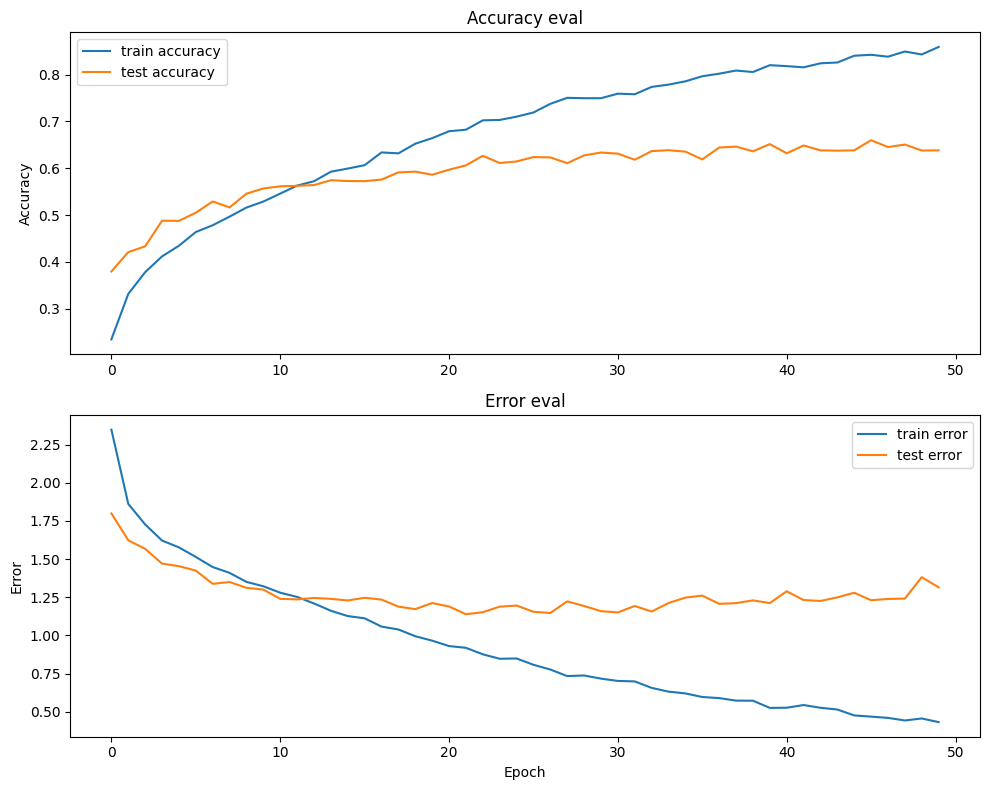

In [12]:
# plot accuracy and error over the epochs 
plot_history(history) 